In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv(r"C:\Users\anujb\Downloads\archive c\Crop_recommendation.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
pd.unique(data["label"])  # checking the unique values in label 

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [4]:
data["label"].value_counts() # checking whether the data is balance or not by using value count.

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [5]:
X = data.drop("label", axis=1) # dropping labels from dataset which eventually means X does'nt contain label column now.
y = data["label"]  # putting label column to y , now value of y will be label column.

In [6]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [7]:
y.head()

0    rice
1    rice
2    rice
3    rice
4    rice
Name: label, dtype: str

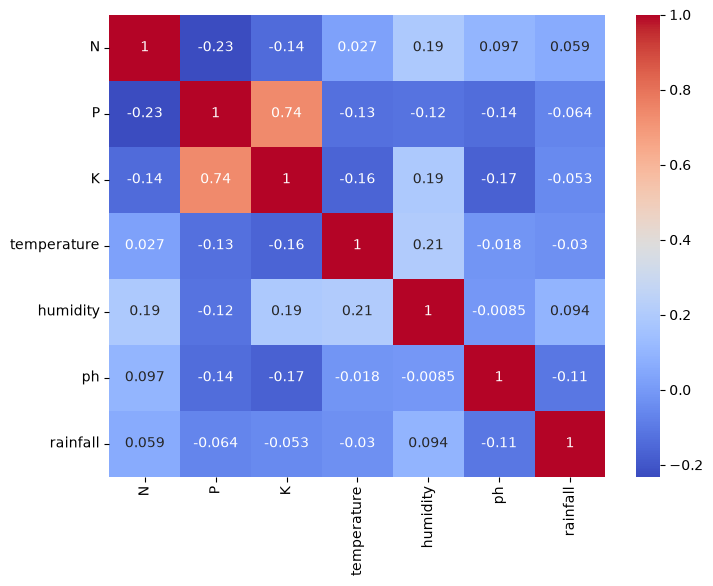

In [8]:
# creating a correlation heatmap:-

X_corr=X.corr(numeric_only=True)  

plt.figure(figsize=(8,6))
sns.heatmap(X_corr,annot=True,cmap='coolwarm')
plt.show()

In [9]:
# Interpretation of Correlation HeatMap:

# from above heatmap we can clearly see there is a strong positive correlation between Phosphorus (P) and Potassium (K).Correlation = 0.74
# So, we can remove one of the column b/c they are highly correlated features carry similar information.

In [10]:
X=X.drop(columns=["P"])

In [11]:
X

,N,K,temperature,humidity,ph,rainfall
0,90,43,20.879744,82.002744,6.502985,202.935536
1,85,41,21.770462,80.319644,7.038096,226.655537
2,60,44,23.004459,82.320763,7.840207,263.964248
3,74,40,26.491096,80.158363,6.980401,242.864034
4,78,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...
2195,107,32,26.774637,66.413269,6.780064,177.774507
2196,99,27,27.417112,56.636362,6.086922,127.924610
2197,118,30,24.131797,67.225123,6.362608,173.322839
2198,117,34,26.272418,52.127394,6.758793,127.175293


In [12]:
scaler= StandardScaler()
scaled_data=scaler.fit_transform(X.values)
X_scaled=pd.DataFrame(scaled_data,columns=X.columns)
X_scaled.head()

,N,K,temperature,humidity,ph,rainfall
0,1.068797,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.121436,-1.083647,0.454792,1.497868,2.898373


In [13]:
# StandardScaler standardizes numerical features by subtracting the mean and dividing by the standard deviation, 
# so that each feature has a mean of approximately 0 and a standard deviation of 1.
# although if we do not standardize it here it doesnt effect that much.(standard scaler usefull in case of L.R,KNN,SVM,Neural Network).

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.model_selection import GridSearchCV

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)
param_grid={
    'criterion': ['gini','entropy'],
    'max_depth': [None,5,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}
clf= DecisionTreeClassifier()
grid_search=GridSearchCV(estimator=clf,param_grid=param_grid,cv=5,scoring='accuracy')
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True

In [16]:
results=pd.DataFrame(grid_search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.019901,0.004013,0.004979,0.001430,gini,None,1,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.974432,0.968750,0.980114,0.982955,0.985795,0.978409,0.006120,1
1,0.016057,0.000662,0.004646,0.000727,gini,None,1,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.971591,0.963068,0.980114,0.982955,0.988636,0.977273,0.008984,6
2,0.015332,0.000260,0.003943,0.000438,gini,None,1,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.965909,0.968750,0.974432,0.980114,0.982955,0.974432,0.006478,14
3,0.015228,0.000307,0.003856,0.000043,gini,None,2,2,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.974432,0.974432,0.977273,0.982955,0.982955,0.978409,0.003854,1
4,0.015397,0.000331,0.004022,0.000236,gini,None,2,5,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.965909,0.977273,0.977273,0.982955,0.982955,0.977273,0.006224,5


In [17]:
best_params=grid_search.best_params_
print("Best Hyperparameters:",best_params)
best_clf=DecisionTreeClassifier(**best_params)
best_clf.fit(X_train,y_train)
y_pred=best_clf.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Best Hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.9704545454545455


In [67]:
best_dt = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best CV Accuracy:
0.978409090909091


In [68]:
y_predDT = best_dt.predict(X_test)

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

dt_accuracy = accuracy_score(y_test, y_predDT)

dt_precision = precision_score(
    y_test,
    y_predDT,
    average='weighted'
)

dt_recall = recall_score(
    y_test,
    y_predDT,
    average='weighted'
)

dt_f1 = f1_score(
    y_test,
    y_predDT,
    average='weighted'
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.9727272727272728
Precision: 0.9738130657221565
Recall   : 0.9727272727272728
F1 Score : 0.9725860089468013


In [70]:
y_probDT = best_dt.predict_proba(X_test)

dt_roc_auc = roc_auc_score(
    y_test,
    y_probDT,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC:", dt_roc_auc)

ROC-AUC: 0.9857352843428987


In [18]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import xgboost
print(xgboost.__version__)

3.3.0


In [20]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
xgb_clf=XGBClassifier()
label_encoder=LabelEncoder()
y_encoded=label_encoder.fit_transform(y)
X_train,X_test,y_trainXG,y_testXG = train_test_split(X_scaled,y_encoded,test_size=0.2,random_state=42)
param_gridX={
    'max_depth': [3,5],
    'learning_rate': [0.1,0.01],
    'n_estimators': [100,200]
}
grid_searchXG=GridSearchCV(estimator=xgb_clf,param_grid=param_gridX,cv=5,scoring='accuracy')
grid_searchXG.fit(X_train,y_trainXG)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.01], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

In [22]:
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score

In [25]:
y_predXG = best_xgb.predict(X_test)

In [28]:
#Accuracy + classification report:-
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_testXG, y_predXG))

print("\nClassification Report:")
print(classification_report(
    y_testXG,
    y_predXG,
    target_names=label_encoder.classes_
))

Accuracy: 0.9863636363636363

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      0.96      0.98        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00     

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

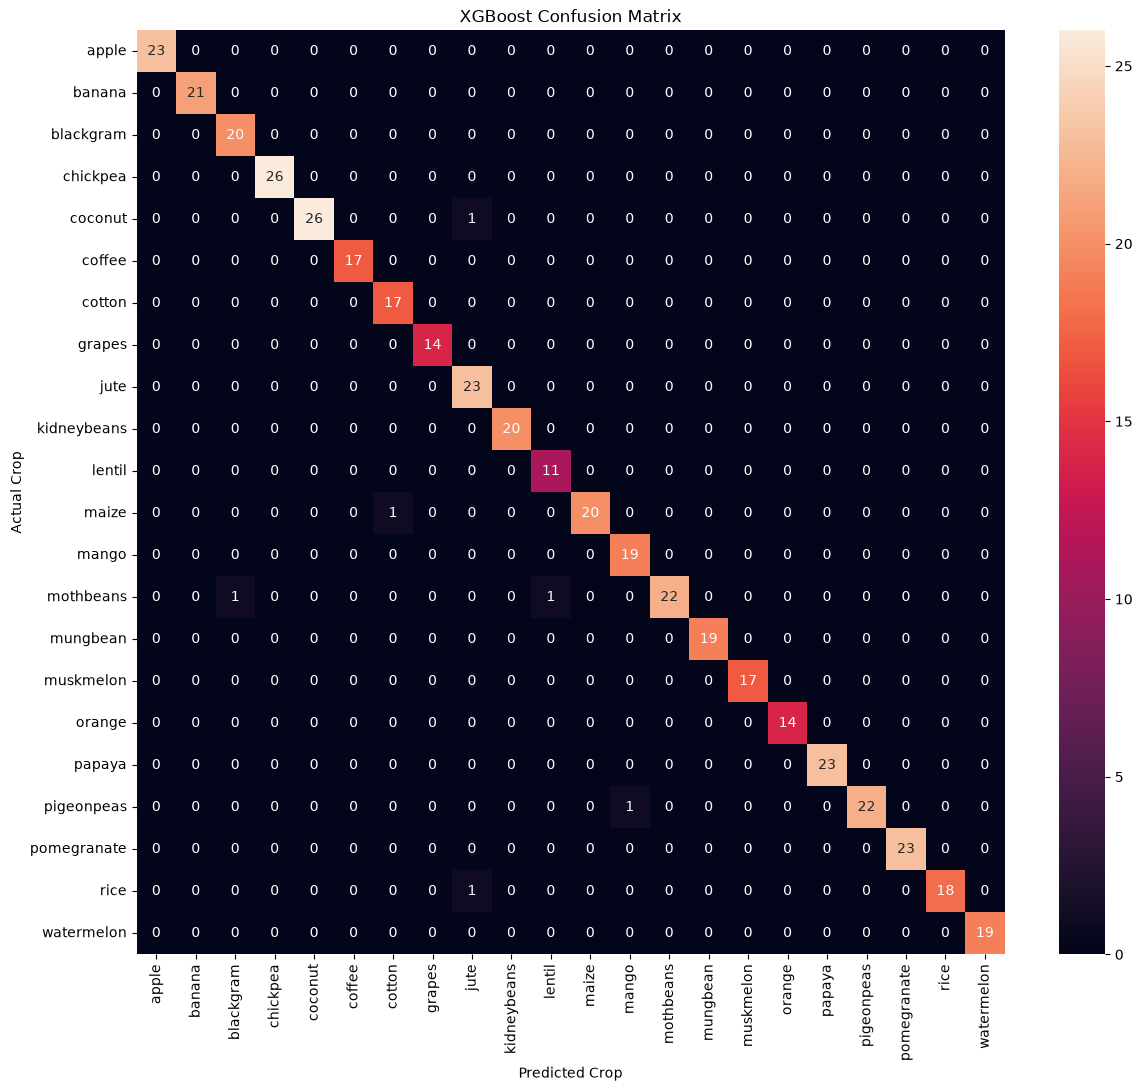

In [31]:
#confusion matrix
cm=confusion_matrix(y_testXG,y_predXG)
plt.figure(figsize=(14,12))
sns.heatmap(
    cm,annot=True,fmt='d',xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("XGBoost Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [32]:
y_probXG = best_xgb.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_testXG,
    y_probXG,
    multi_class='ovr',
    average='weighted'
)

print("Multiclass ROC-AUC:", roc_auc)

Multiclass ROC-AUC: 0.9994473466081815


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

K              0.231465
humidity       0.210530
rainfall       0.206871
N              0.151331
temperature    0.108621
ph             0.091183
dtype: float32


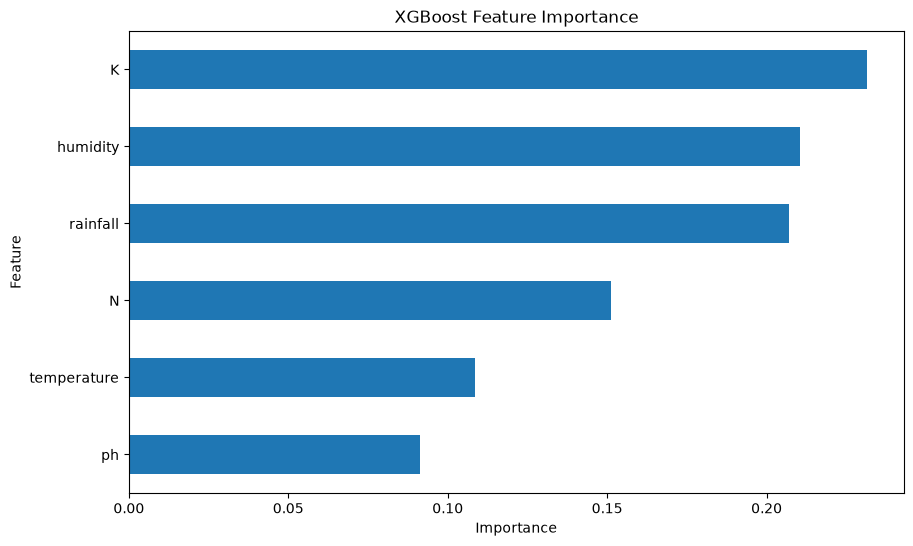

In [34]:
#plotting feature importance
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.show()

In [ ]:
#

In [35]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 402.3 kB/s eta 0:01:43
    --------------------------------------- 0.5/41.9 MB 402.3 kB/s eta 0:01:43
    --------------------------------------- 0.8/41.9 MB 465.4 kB/s eta 0:01:29
    --------------------------------------- 0.8/41.9 MB 465.4 kB/s eta 0:01:29
   - -------------------------------------- 1.0/41.9 MB 523.0 kB/s eta 0:01:19
   - -------------------------------------- 1.3/41.9 MB 599.2 kB/s eta 0:01:08
   - -------------------------------------- 1.3/41.9 MB 599.2 kB/s eta 0:01:08
   - ----------------------


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(440, 6, 22)


In [38]:
#22 → crop classes

In [37]:
print(X_test.columns)

Index(['N', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')


In [40]:
#Calculate overall SHAP importance
import numpy as np
import pandas as pd

mean_shap = np.abs(shap_values).mean(axis=(0, 2)) #abs is used to make negative value into positve value (mode)

shap_importance = pd.Series(
    mean_shap,
    index=X_test.columns
).sort_values(ascending=False)

print(shap_importance)

humidity       1.084497
rainfall       1.033270
K              0.911559
N              0.600678
temperature    0.207020
ph             0.174520
dtype: float32


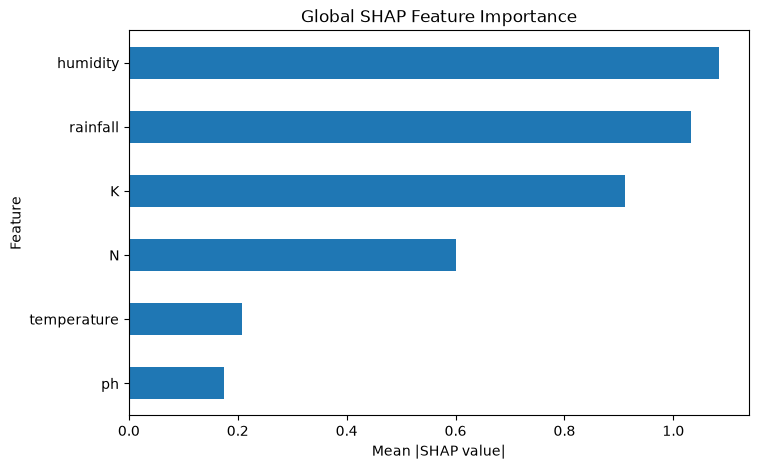

In [41]:
import matplotlib.pyplot as plt

shap_importance.sort_values().plot(kind='barh', figsize=(8, 5))

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance")

plt.show()

In [43]:
#SHAP for one specific crop
rice_class = label_encoder.transform(['rice'])[0]

print(rice_class)

20


In [44]:
rice_shap = shap_values[:, :, rice_class]

print(rice_shap.shape)

(440, 6)


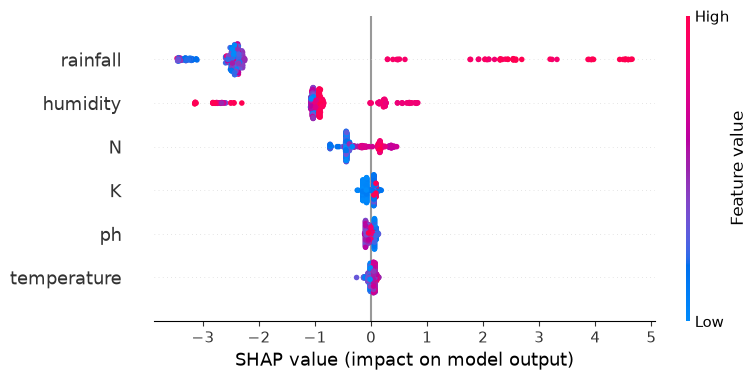

In [46]:
#Which features influence the model's prediction of Rice across the test dataset
shap.summary_plot(
    rice_shap,
    X_test,
    feature_names=X_test.columns
)

In [47]:
sample_index = 0

sample = X_test.iloc[sample_index]

print(sample)

N              1.366828
K             -0.022693
temperature    0.765964
humidity       1.044445
ph            -0.367590
rainfall      -1.404208
Name: 1451, dtype: float64


In [48]:
prediction = best_xgb.predict(
    sample.to_frame().T
)[0]

predicted_crop = label_encoder.inverse_transform([prediction])[0]

print("Predicted Crop:", predicted_crop)

Predicted Crop: muskmelon


In [49]:
sample_shap = shap_values[
    sample_index,
    :,
    prediction
]

print(
    pd.Series(
        sample_shap,
        index=X_test.columns
    ).sort_values()
)

N              0.000000
K              0.000000
temperature    0.000000
ph             0.000000
humidity       0.046911
rainfall       5.931276
dtype: float32


For this particular prediction, K, humidity, and rainfall contributed positively toward the predicted crop, while pH had a smaller negative contribution.

In [52]:
sample_index = 0

prediction = best_xgb.predict(
    X_test.iloc[[sample_index]]
)[0]

predicted_crop = label_encoder.inverse_transform([prediction])[0]

print("Predicted Crop:", predicted_crop)

sample_shap = shap_values[
    sample_index,
    :,
    prediction
]

explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": X_test.iloc[sample_index].values,
    "SHAP Value": sample_shap
})

print(explanation.sort_values("SHAP Value", key=abs, ascending=False))

Predicted Crop: muskmelon
       Feature     Value  SHAP Value
5     rainfall -1.404208    5.931276
3     humidity  1.044445    0.046911
1            K -0.022693    0.000000
0            N  1.366828    0.000000
2  temperature  0.765964    0.000000
4           ph -0.367590    0.000000


In [54]:
# Select the sample
sample_index = 0

# Get encoded prediction
prediction = best_xgb.predict(
    X_test.iloc[[sample_index]]
)[0]

# Convert encoded class to crop name
predicted_crop = label_encoder.inverse_transform([prediction])[0]

# Store the predicted class
predicted_class = prediction

print("Predicted Crop:", predicted_crop)
print("Encoded Class:", predicted_class)

Predicted Crop: muskmelon
Encoded Class: 15


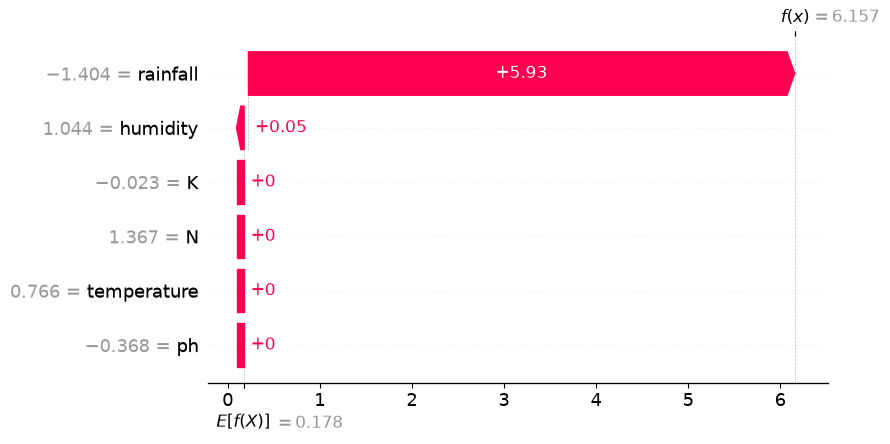

In [55]:
shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value[predicted_class],
        data=X_test.iloc[sample_index].values,
        feature_names=X_test.columns
    )
)

In [57]:
print(best_xgb.get_booster().get_score(importance_type='gain'))

{'N': 8.216602325439453, 'K': 12.567544937133789, 'temperature': 5.897645473480225, 'humidity': 11.43085765838623, 'ph': 4.950863838195801, 'rainfall': 11.232224464416504}


In [60]:
print(best_xgb.get_booster().get_score(importance_type='weight'))

{'N': 853.0, 'K': 1043.0, 'temperature': 506.0, 'humidity': 1426.0, 'ph': 474.0, 'rainfall': 1260.0}


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [64]:
xgb_accuracy = accuracy_score(y_testXG, y_predXG)

xgb_precision = precision_score(
    y_testXG, y_predXG,
    average='weighted'
)

xgb_recall = recall_score(
    y_testXG, y_predXG,
    average='weighted'
)

xgb_f1 = f1_score(
    y_testXG, y_predXG,
    average='weighted'
)

xgb_roc_auc = roc_auc_score(
    y_testXG,
    y_probXG,
    multi_class='ovr',
    average='weighted'
)

print("XGBoost")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1       :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)


XGBoost
Accuracy : 0.9863636363636363
Precision: 0.9872647907647908
Recall   : 0.9863636363636363
F1       : 0.9863931254010212
ROC-AUC  : 0.9994473466081815


In [71]:
comparison = pd.DataFrame({
    'Model': ['Tuned Decision Tree', 'Tuned XGBoost'],
    'Accuracy': [dt_accuracy, xgb_accuracy],
    'Precision': [dt_precision, xgb_precision],
    'Recall': [dt_recall, xgb_recall],
    'F1 Score': [dt_f1, xgb_f1],
    'ROC-AUC': [dt_roc_auc, xgb_roc_auc]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Tuned Decision Tree  0.972727   0.973813  0.972727  0.972586  0.985735
1        Tuned XGBoost  0.986364   0.987265  0.986364  0.986393  0.999447


In [72]:
import joblib

joblib.dump(best_xgb, "crop_xgboost_model.pkl")
joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("Model and label encoder saved successfully!")

Model and label encoder saved successfully!


In [80]:
joblib.dump(scaler, "crop_scaler.pkl")

['crop_scaler.pkl']

In [79]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [75]:
def predict_crop(N, K, temperature, ph, humidity, rainfall):

    input_data = [[
        N,
        K,
        temperature,
        ph,
        humidity,
        rainfall
    ]]

    input_scaled = scaler.transform(input_data)

    prediction = best_xgb.predict(input_scaled)

    crop = label_encoder.inverse_transform(prediction)[0]

    return crop

In [81]:
result = predict_crop(
    N=90,
    K=40,
    temperature=25,
    ph=6.5,
    humidity=80,
    rainfall=200
)

print("Recommended Crop:", result)

ValueError: The feature names should match those that were passed during fit.
Feature names must be in the same order as they were in fit.


In [77]:
import pandas as pd

def predict_crop(N, K, temperature, ph, humidity, rainfall):

    input_data = pd.DataFrame([{
        'N': N,
        'K': K,
        'temperature': temperature,
        'ph': ph,
        'humidity': humidity,
        'rainfall': rainfall
    }])

    input_scaled = scaler.transform(input_data)

    prediction = best_xgb.predict(input_scaled)

    crop = label_encoder.inverse_transform(prediction)[0]

    return crop

In [82]:
incorrect = X_test[y_testXG != y_predXG]

print("Incorrect predictions:", len(incorrect))
print("Total test samples:", len(y_testXG))

Incorrect predictions: 6
Total test samples: 440


In [83]:
error_indices = np.where(y_testXG != y_predXG)[0]

print("Number of errors:", len(error_indices))

Number of errors: 6


In [84]:
error_df = pd.DataFrame({
    'Actual': label_encoder.inverse_transform(
        y_testXG[error_indices]
    ),
    'Predicted': label_encoder.inverse_transform(
        y_predXG[error_indices]
    )
})

print(error_df)

       Actual  Predicted
0  pigeonpeas      mango
1   mothbeans  blackgram
2       maize     cotton
3        rice       jute
4     coconut       jute
5   mothbeans     lentil


In [85]:
error_df.value_counts()

Actual      Predicted
pigeonpeas  mango        1
mothbeans   blackgram    1
maize       cotton       1
rice        jute         1
coconut     jute         1
mothbeans   lentil       1
Name: count, dtype: int64

1. Problem Statement
2. Dataset
3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Decision Tree Model
7. Decision Tree Hyperparameter Tuning
8. XGBoost Model
9. XGBoost Hyperparameter Tuning
10. Model Evaluation
11. Model Comparison
12. Feature Importance
13. SHAP Explainability
14. Error Analysis
15. Final Conclusion

In [87]:
gain_importance = best_xgb.get_booster().get_score(
    importance_type='gain'
)

feature_importance_df = pd.DataFrame({
    'Feature': list(gain_importance.keys()),
    'Gain': list(gain_importance.values())
})

feature_importance_df = feature_importance_df.sort_values(
    by='Gain',
    ascending=False
)

print(feature_importance_df)

       Feature       Gain
1            K  12.567545
3     humidity  11.430858
5     rainfall  11.232224
0            N   8.216602
2  temperature   5.897645
4           ph   4.950864


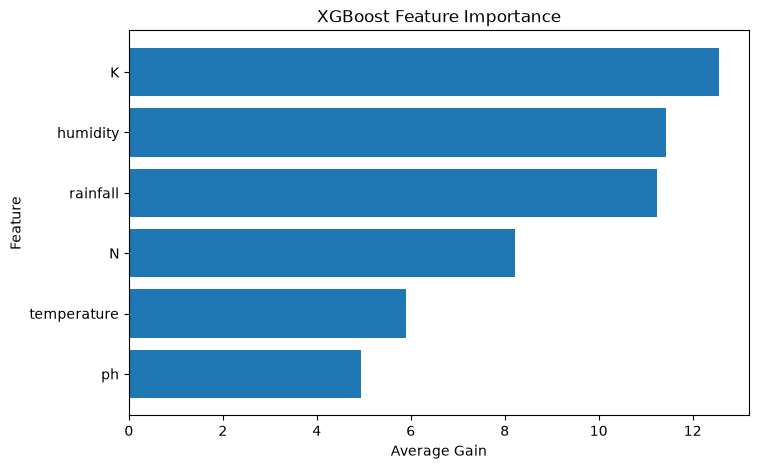

In [88]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Gain']
)

plt.xlabel("Average Gain")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Conclusion
- The tuned XGBoost classifier performed better than the tuned Decision Tree across all major evaluation metrics.
- XGBoost achieved 98.64% accuracy, 98.73% weighted precision, 98.64% weighted recall, 98.64% weighted F1-score, and 99.94% weighted ROC-AUC.
- Feature importance analysis showed that potassium (K), humidity, and rainfall were among the most influential features used by the model. 
- SHAP analysis was additionally used to understand how individual features contributed to specific crop predictions.

In [89]:
print("XGBoost Best CV Accuracy:", grid_searchXG.best_score_)
print("XGBoost Test Accuracy:", xgb_accuracy)

XGBoost Best CV Accuracy: 0.9846590909090909
XGBoost Test Accuracy: 0.9863636363636363
